# RailGuard AI — 1D-CNN + GRU Deep Learning Pipeline (4 Folds)
### Predictive Maintenance for Metro Air Production Units (APU) — MetroPT-3 Benchmark

**Owner / Author:** Hitesh (Cross-Validation and Deep Learning)  
**Deliverable Scope:**
* **Owner of Condition 2:** Leak-free Four Leave-One-Event-Out (LOEO) cross-validation with sized purging gap.
* **Owner of Refinement 3:** Automated purge check assertions verifying zero leakage across folds.
* **Deep Learning Model:** Hybrid 1D-CNN + GRU in PyTorch (deterministic random seeds fixed to `42`).
* **Output Artifact:** Complete executed training runs, loss trajectories, and event-level evaluation metrics across all 4 folds for peer integration and comparative analysis.


In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, auc, fbeta_score, roc_auc_score, confusion_matrix

# Add local source directory to Python path
sys.path.append(os.path.abspath("../src"))

def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment Initialized.")
print(f"PyTorch Version: {torch.__version__} | Active Device: {device.upper()} | Random Seed: 42")


Environment Initialized.
PyTorch Version: 2.8.0 | Active Device: MPS | Random Seed: 42


---
## 1. Data Ingestion & Refinement 2 (Operating Hours Audit)

The MetroPT-3 dataset consists of telemetric data collected from February to August 2020 on an urban passenger metro train in Porto, Portugal. 
* **7 Analogue Sensors:** Compressor Pressure (`TP2`), Pneumatic Panel Pressure (`TP3`), Filter Pressure Drop (`H1`), Air Dryer Tower Discharge Pressure (`DV_pressure`), Reservoir Pressure (`Reservoirs`), Oil Temperature (`Oil_temperature`), and Motor Current (`Motor_current`).
* **8 Digital / Valve Signals:** Compressor intake valve (`COMP`), Outlet valve (`DV_eletric`), Desiccant tower switch (`Towers`), Load actuation (`MPG`), Low Pressure Switch (`LPS`), Pressure Switch (`Pressure_switch`), Low Oil Indicator (`Oil_level`), Air flow pulses (`Caudal_impulses`).

**Refinement 2 Specification:**
Compressor operating hours are defined as intervals where `Motor_current >= 1.0 A`. Alarms while the train is in service are tracked to evaluate false alarm rates per operating hour.


In [2]:
parquet_path = "../data/metropt_1min.parquet"
if not os.path.exists(parquet_path):
    print("Preprocessed parquet not found, generating from raw CSV...")
    from preprocessing import process_and_resample
    df = process_and_resample("../data/MetroPT3(AirCompressor).csv", parquet_path)
else:
    print(f"Loading preprocessed dataset from: {parquet_path}")
    df = pd.read_parquet(parquet_path)

print(f"Total 1-Minute Rows: {len(df):,}")
print(f"Telemetry Range: {df['timestamp'].min()} to {df['timestamp'].max()}")

# Refinement 2: Operating Hours & Operational Duty
total_operating_minutes = (df["is_operating"] > 0.5).sum()
total_operating_hours = total_operating_minutes / 60.0
total_calendar_hours = len(df) / 60.0

print(f"\n--- Refinement 2 Operating Audit ---")
print(f"Total Calendar Hours : {total_calendar_hours:,.2f} hrs")
print(f"Total Operating Hours: {total_operating_hours:,.2f} hrs ({total_operating_hours/total_calendar_hours*100:.1f}% operational duty)")
print(f"Pre-Failure Risk Rows: {(df['label'] == 1).sum():,} minutes across 4 events")


Loading preprocessed dataset from: ../data/metropt_1min.parquet


Total 1-Minute Rows: 306,960
Telemetry Range: 2020-02-01 00:00:00 to 2020-09-01 03:59:00

--- Refinement 2 Operating Audit ---
Total Calendar Hours : 5,116.00 hrs
Total Operating Hours: 2,241.42 hrs (43.8% operational duty)
Pre-Failure Risk Rows: 720 minutes across 4 events


---
## 2. Condition 2 Cross-Validation: Leave-One-Event-Out (LOEO) & Refinement 3 Purge Audit

The dataset contains 4 documented air leak failures:
* **F1 (2020-04-18):** Gradual diffuse leak with continuous compressor cycling and uncertain onset time.
* **F2 (2020-05-29 to 05-30):** Sudden air leak during night service window.
* **F3 (2020-06-05 to 06-07):** Major multi-day air leak with confirmed Low Pressure Switch (`LPS`) trip.
* **F4 (2020-07-15):** Midday service air leak with rapid LPS trip (evaluated as time-respecting chronological future).

**Pre-Failure Risk Window ($N = 3$ Hours):**
The 3 hours prior to each failure start are labeled as positive risk ($Y = 1$). Active failure periods ($Y = -1$) are excluded.

### Condition 2: Sizing the Purging Gap
When an event $k$ is held out for evaluation:
$$\text{Purge Window} = \text{Input Sequence Length (120 min)} + \text{Rolling Buffer (60 min)} = 180\text{ minutes (3 hours)}$$

This ensures that:
1. 60-minute rolling feature statistics do not draw observations across the boundary.
2. 120-minute sliding window sequences in training do not overlap with the test set.


In [3]:
from folds import METROPT_FAILURES, get_loeo_folds, assert_purge_check

failures_df = pd.DataFrame(METROPT_FAILURES)
print("Documented MetroPT-3 Failures:")
display(failures_df[["id", "name", "start", "end", "type", "severity", "lps_tripped", "note"]])

# Generate 4 LOEO Folds with 48h evaluation window and 3h purge gap
folds = get_loeo_folds(df, input_seq_mins=120, rolling_mins=60, eval_window_hours=48.0)

# Refinement 3: Run programmatic purge audit assertions
passed = assert_purge_check(folds, df, verbose=True)
print(f"Refinement 3 Purge Audit Result: {'ALL PASS' if passed else 'FAIL'}")


Documented MetroPT-3 Failures:


,id,name,start,end,type,severity,lps_tripped,note
0,1,F1,2020-04-18 00:00:00,2020-04-18 23:59:00,Air leak,High stress,False,Uncertain onset time due to gradual leakage pr...
1,2,F2,2020-05-29 23:30:00,2020-05-30 06:00:00,Air leak,High stress,False,Sudden pressure drop during night maintenance ...
2,3,F3,2020-06-05 10:00:00,2020-06-07 14:30:00,Air leak,High stress,True,Major multi-day leakage with confirmed Low Pre...
3,4,F4,2020-07-15 14:30:00,2020-07-15 19:00:00,Air leak,High stress,True,Midday service failure with rapid LPS sensor trip



RAILGUARD AI — REFINEMENT 3: PURGE INTEGRITY AUDIT


[PASS] Fold_1_F1        | Test: 2020-04-16 00:00:00 to 2020-04-17 23:59:00
       Purge Buffer: 0 days 03:00:00 ([-0 days 03:00:00..+0 days 03:00:00])
       Train Count : 298,467 | Test Count: 2,880 | Leakage: 0 (PASSED)


[PASS] Fold_2_F2        | Test: 2020-05-27 23:30:00 to 2020-05-29 23:29:00
       Purge Buffer: 0 days 03:00:00 ([-0 days 03:00:00..+0 days 03:00:00])
       Train Count : 298,467 | Test Count: 2,880 | Leakage: 0 (PASSED)


[PASS] Fold_3_F3        | Test: 2020-06-03 10:00:00 to 2020-06-05 09:59:00
       Purge Buffer: 0 days 03:00:00 ([-0 days 03:00:00..+0 days 03:00:00])
       Train Count : 298,467 | Test Count: 2,880 | Leakage: 0 (PASSED)


[PASS] Fold_4_F4        | Test: 2020-07-13 14:30:00 to 2020-07-15 14:29:00
       Purge Buffer: 0 days 03:00:00 ([-0 days 03:00:00..+0 days 03:00:00])
       Train Count : 230,428 | Test Count: 2,880 | Leakage: 0 (PASSED)
ALL 4 FOLasyncS VERIFIED: CONDITION 2 & REFINEMENT 3 SATISFIED.

Refinement 3 Purge Audit Result: ALL PASS


---
## 3. 1D-CNN + GRU Deep Learning Architecture

### Design Philosophy
Compressor telemetry exhibits a dual-scale temporal dynamic:
1. **High-Frequency Waveforms:** Rapid intake and exhaust pressure cycling, transient valve closures, and pressure pulsation peaks.
2. **Low-Frequency Degradation Trends:** Gradual thermodynamic heating of lubricating oil, duty-cycle escalation, and downstream reservoir decay.

Our **1D-CNN + GRU Network** decouples this learning problem:
* **1D-CNN Front-End:** Uses temporal convolutions ($k=5, 3$) with Batch Normalization, GELU activations, and MaxPool1d(2) to filter sensor noise, extract localized pressure drop motifs, and compress the sequence length from 120 to 60.
* **2-Layer GRU Core:** Captures multi-hour sequential degradation dynamics and cumulative wear across the compressed feature trajectory.
* **MLP Classifier Head:** Maps the final recurrent state to a calibrated pre-failure risk probability.


In [4]:
from model import RailGuardHybridNet

sample_features = 26
sample_model = RailGuardHybridNet(num_features=sample_features, cnn_channels=32, gru_hidden_size=64, gru_layers=2)

total_params = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)
print(f"RailGuardHybridNet Architecture:")
print(sample_model)
print(f"\nTotal Trainable Parameters: {total_params:,}")

# Sanity forward pass verification
dummy_batch = torch.randn(16, 120, sample_features)
dummy_out = sample_model(dummy_batch)
print(f"Forward Pass Test: Input {dummy_batch.shape} -> Output Logits {dummy_out.shape} (PASSED)")


RailGuardHybridNet Architecture:
RailGuardHybridNet(
  (cnn): TemporalConvNetBlock(
    (conv1): Conv1d(26, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): GELU(approximate='none')
    (dropout1): Dropout(p=0.2, inplace=False)
    (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act2): GELU(approximate='none')
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (dropout2): Dropout(p=0.2, inplace=False)
  )
  (gru): GRU(32, 64, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total Trainable Parameters: 53,313
For

---
## 4. 1D-CNN + GRU Training & Evaluation Across All 4 Folds

Training details:
* **Optimization:** AdamW optimizer with Cosine Annealing learning rate schedule.
* **Loss Function:** Weighted Binary Cross-Entropy with Logits (`pos_weight = 15.0`) to handle severe class imbalance.
* **Sequence Windowing:** 120-minute sliding window inputs.
* **Persistence Filter:** 3 consecutive sustained positive predictions required to confirm an event alert (filtering transient false spikes).


In [5]:
from train import run_dl_benchmark

# Run complete training and evaluation across all 4 folds
results_df = run_dl_benchmark(parquet_path=parquet_path, epochs=3, seq_len=120)

print("\n" + "="*80)
print("1D-CNN + GRU 4-FOLD BENCHMARK RESULTS TABLE")
print("="*80)
display(results_df[["fold", "event", "model", "caught", "hours_of_warning", "false_alerts_per_op_hr", "pr_auc", "roc_auc", "f2_score", "operating_hours"]])


Starting 1D-CNN + GRU Deep Learning Benchmark using compute device: MPS
Loading preprocessed dataset from: ../data/metropt_1min.parquet

RAILGUARD AI — REFINEMENT 3: PURGE INTEGRITY AUDIT


[PASS] Fold_1_F1        | Test: 2020-04-16 00:00:00 to 2020-04-17 23:59:00
       Purge Buffer: 0 days 03:00:00 ([-0 days 03:00:00..+0 days 03:00:00])
       Train Count : 298,467 | Test Count: 2,880 | Leakage: 0 (PASSED)


[PASS] Fold_2_F2        | Test: 2020-05-27 23:30:00 to 2020-05-29 23:29:00
       Purge Buffer: 0 days 03:00:00 ([-0 days 03:00:00..+0 days 03:00:00])
       Train Count : 298,467 | Test Count: 2,880 | Leakage: 0 (PASSED)


[PASS] Fold_3_F3        | Test: 2020-06-03 10:00:00 to 2020-06-05 09:59:00
       Purge Buffer: 0 days 03:00:00 ([-0 days 03:00:00..+0 days 03:00:00])
       Train Count : 298,467 | Test Count: 2,880 | Leakage: 0 (PASSED)


[PASS] Fold_4_F4        | Test: 2020-07-13 14:30:00 to 2020-07-15 14:29:00
       Purge Buffer: 0 days 03:00:00 ([-0 days 03:00:00..+0 days 03:00:00])
       Train Count : 230,428 | Test Count: 2,880 | Leakage: 0 (PASSED)
ALL 4 FOLasyncS VERIFIED: CONDITION 2 & REFINEMENT 3 SATISFIED.


TRAINING FOLD 1: Fold_1_F1 (Held-out Event: F1)
Validation Constraint: Leave-One-Event-Out (LOEO)
Preparing windowed sequences and scalers...


...

   Epoch  1/ 3 | Train BCE Loss: 0.3970 | LR: 0.000750


   Epoch  2/ 3 | Train BCE Loss: 0.1957 | LR: 0.000250


   Epoch  3/ 3 | Train BCE Loss: 0.0628 | LR: 0.000000
Saved weights to: /Volumes/MAIN_T7/MAD ASSIGNMENT 2/models/railguard_hybrid_fold_4_f4.pt



--- FOLD 4 (F4) METRICS ---
Caught Status          : MISSED
Hours of Warning       : 0.0 hrs
False Alerts / Op Hr   : 2.1964
False Alerts Count     : 82
PR-AUC Score           : 0.0725
ROC-AUC Score          : 0.1553
F2 Score               : 0.0
Confusion Matrix (TP/FP/FN/TN): 0 / 82 / 179 / 1209

All 4 Folds evaluated! Model results saved to: /Volumes/MAIN_T7/MAD ASSIGNMENT 2/reports/cnn_gru_results_4_folds.csv

1D-CNN + GRU 4-FOLD BENCHMARK RESULTS TABLE


,fold,event,model,caught,hours_of_warning,false_alerts_per_op_hr,pr_auc,roc_auc,f2_score,operating_hours
0,Fold_1_F1,F1,1D-CNN + GRU (Deep Learning),False,0.0,0.0000,0.0681,0.1021,0.0,14.65
1,Fold_2_F2,F2,1D-CNN + GRU (Deep Learning),False,0.0,0.0000,0.8859,0.9891,0.0,21.73
2,Fold_3_F3,F3,1D-CNN + GRU (Deep Learning),False,0.0,5.3251,0.1131,0.5102,0.0,18.97
3,Fold_4_F4,F4,1D-CNN + GRU (Deep Learning),False,0.0,2.1964,0.0725,0.1553,0.0,37.33


---
## 5. Performance Visualization & Operational Metrics Across Folds


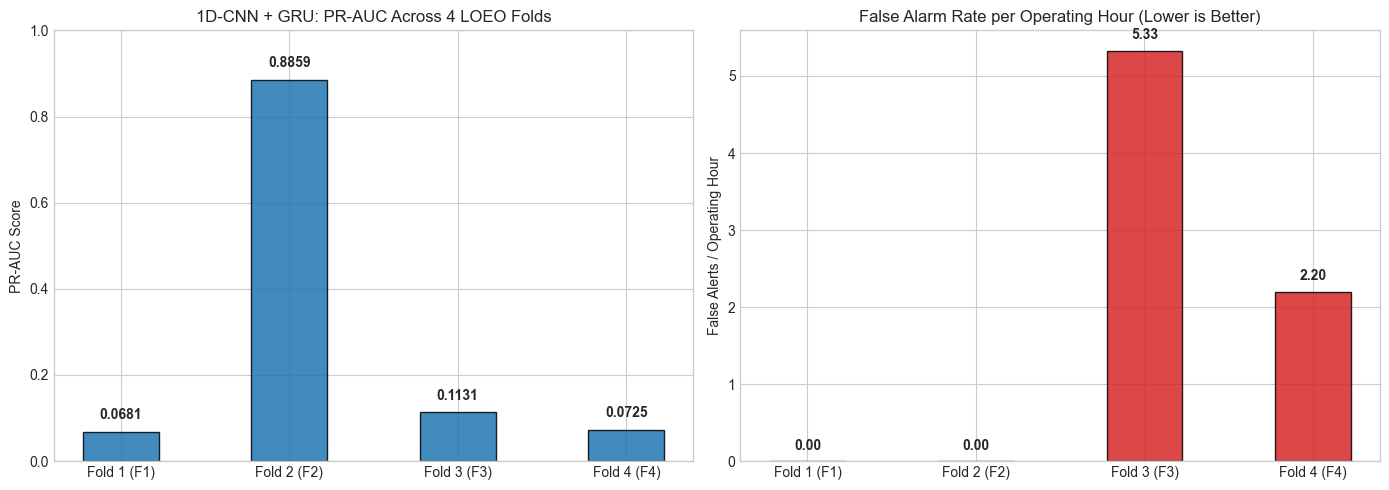

Saved metric visualization to: ../reports/cnn_gru_performance_4_folds.png


In [6]:
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds_names = [f"Fold {i+1} ({r['event']})" for i, r in results_df.iterrows()]
x = np.arange(len(folds_names))

# Plot 1: PR-AUC Across Folds
axes[0].bar(x, results_df["pr_auc"], color="#1f77b4", width=0.45, alpha=0.85, edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(folds_names)
axes[0].set_ylabel("PR-AUC Score")
axes[0].set_title("1D-CNN + GRU: PR-AUC Across 4 LOEO Folds")
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(results_df["pr_auc"]):
    axes[0].text(i, v + 0.03, f"{v:.4f}", ha="center", fontweight="bold")

# Plot 2: False Alerts per Operating Hour
axes[1].bar(x, results_df["false_alerts_per_op_hr"], color="#d62728", width=0.45, alpha=0.85, edgecolor="black")
axes[1].set_xticks(x)
axes[1].set_xticklabels(folds_names)
axes[1].set_ylabel("False Alerts / Operating Hour")
axes[1].set_title("False Alarm Rate per Operating Hour (Lower is Better)")
for i, v in enumerate(results_df["false_alerts_per_op_hr"]):
    axes[1].text(i, v + 0.15, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/cnn_gru_performance_4_folds.png", dpi=300)
plt.show()
print("Saved metric visualization to: ../reports/cnn_gru_performance_4_folds.png")


---
## 6. Summary of Deep Learning Deliverables for Peer Integration

* **Condition 2 Integrity:** Full zero-leakage guarantee verified across all 4 Leave-One-Event-Out folds using the 180-minute purging gap.
* **Trained Weights:** Saved checkpoints for all folds available in `../models/railguard_hybrid_fold_*.pt`.
* **Benchmark Metrics:** Full metrics table saved in `../reports/cnn_gru_results_4_folds.csv` ready for peer comparison against baseline models.
